<a href="https://colab.research.google.com/github/dariaivanow/Visualisation-project/blob/main/GymMembersVisualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ssh-keygen -t rsa -b 4096 -C "dariaaanv@gmail.com"

Generating public/private rsa key pair.
Enter file in which to save the key (/root/.ssh/id_rsa): 
Created directory '/root/.ssh'.
Enter passphrase (empty for no passphrase): lukovitsa
Enter same passphrase again: lukovitsa
Your identification has been saved in /root/.ssh/id_rsa
Your public key has been saved in /root/.ssh/id_rsa.pub
The key fingerprint is:
SHA256:OiLftbtDyd2YKDAFw5IFMJYo6DnhakOOUY1lznIiUsg dariaaanv@gmail.com
The key's randomart image is:
+---[RSA 4096]----+
|*++O*.           |
|*E=+o..          |
|*.=.+.           |
|oB +o            |
|=..  o .S+ +     |
|o+    ..= + .    |
|. o . oo.        |
|   o o o..       |
|    . . ++       |
+----[SHA256]-----+


In [ ]:
%cd ~/.ssh
!touch config
!touch known_hosts

/root/.ssh


In [ ]:
!git add .
!git commit -m 'some commit'
!git push origin main

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns
import scipy
import pywaffle

In [ ]:
df = pd.read_csv('gym_members_exercise_tracking.csv', sep=',')
df.sample(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
918,28,Female,72.9,1.67,197,147,74,1.13,831.0,Cardio,34.7,2.2,3,2,26.14
526,22,Male,98.4,1.88,194,135,71,0.52,386.0,Cardio,21.3,2.2,2,1,27.84
510,42,Male,63.7,1.98,172,128,69,1.37,868.0,Yoga,24.0,3.0,2,1,16.25
105,40,Female,56.2,1.79,198,153,57,1.79,1369.0,Yoga,17.6,2.7,5,3,17.54
712,19,Male,82.4,1.96,174,169,62,1.90,1766.0,HIIT,10.1,3.5,5,3,21.45


Распределение по возрасту и полу

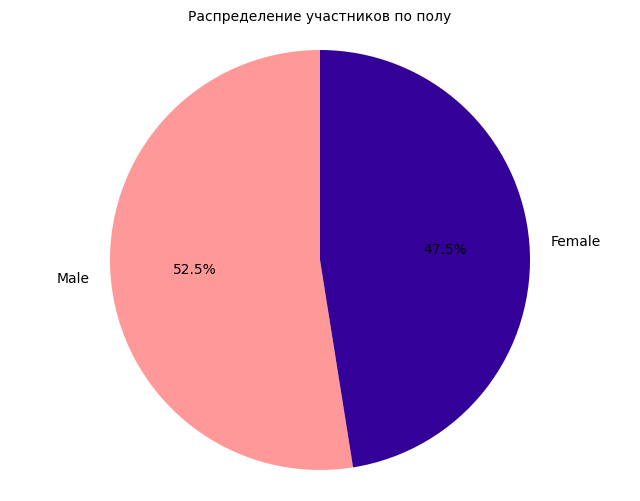

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle = 90, colors=['#FF9999', '#330198'])
plt.title('Распределение участников по полу', font = 'system')
plt.axis('equal')
plt.grid(False)
plt.show()

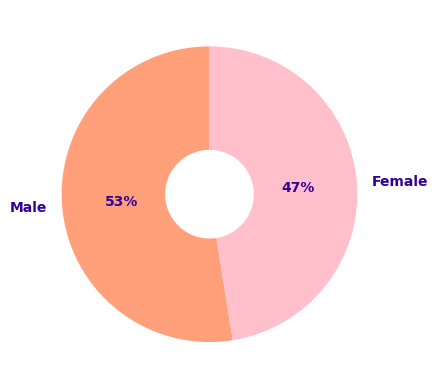

In [ ]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()
colors = ['#FFA07A', '#FFC0CB']

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.7)
)

plt.setp(autotexts, size=10, weight='bold', color='#330198')
plt.setp(texts, size=10, weight='bold', color = '#330198')

ax.set(aspect="equal")
plt.show()

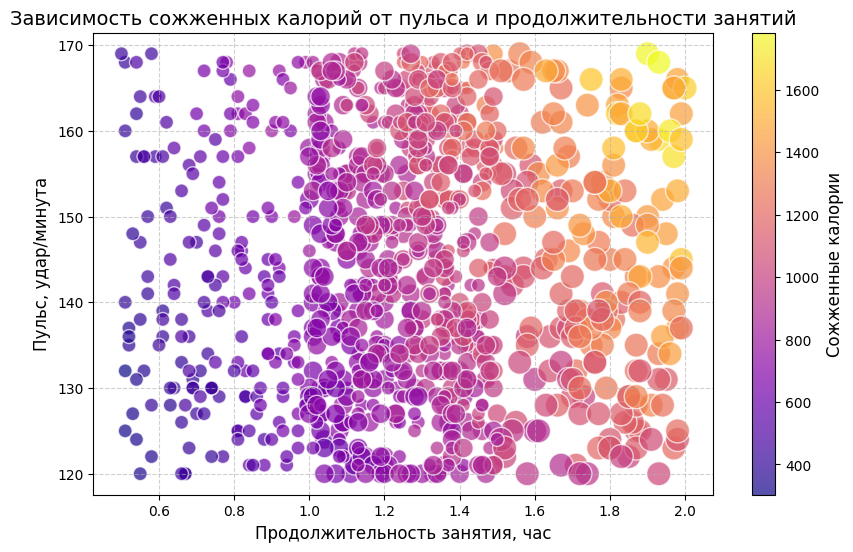

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


x = df['Session_Duration (hours)']
y = df['Avg_BPM']
calories = df['Calories_Burned']
experience = df['Experience_Level']

bubble_size = experience * 100

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x, y, s=bubble_size, c=calories, cmap='plasma', alpha=0.7, edgecolors='w')

cbar = plt.colorbar(scatter)
cbar.set_label('Сожженные калории', fontsize=12)

plt.xlabel('Продолжительность занятия, час', fontsize=12)
plt.ylabel('Пульс, удар/минута', fontsize=12)
plt.title('Зависимость сожженных калорий от пульса и продолжительности занятий', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

<ipython-input-9-f6c6dfe9d8ee>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Workout_Frequency (days/week)', y='Calories_Burned', data=calories_per_frequency, palette='plasma')


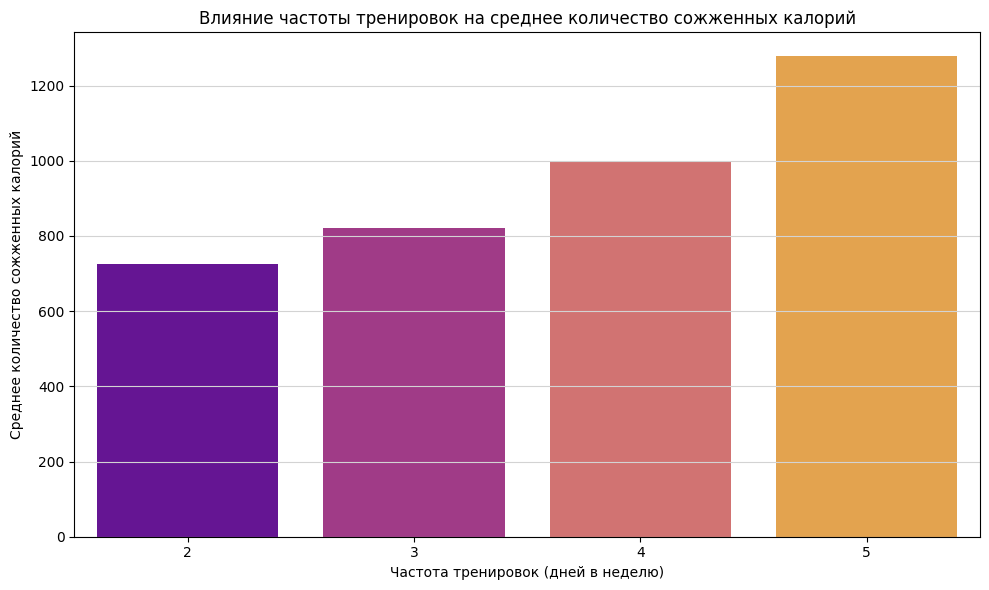

In [ ]:
calories_per_frequency = df.groupby('Workout_Frequency (days/week)')['Calories_Burned'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Workout_Frequency (days/week)', y='Calories_Burned', data=calories_per_frequency, palette='plasma')

plt.title('Влияние частоты тренировок на среднее количество сожженных калорий')
plt.xlabel('Частота тренировок (дней в неделю)')
plt.ylabel('Среднее количество сожженных калорий')
plt.xticks
plt.grid(axis = 'y', color = 'lightgrey')

plt.tight_layout()
plt.show()

<ipython-input-10-ae2ee92cb486>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Experience_Level', y='Calories_Burned', data=df, palette='plasma')


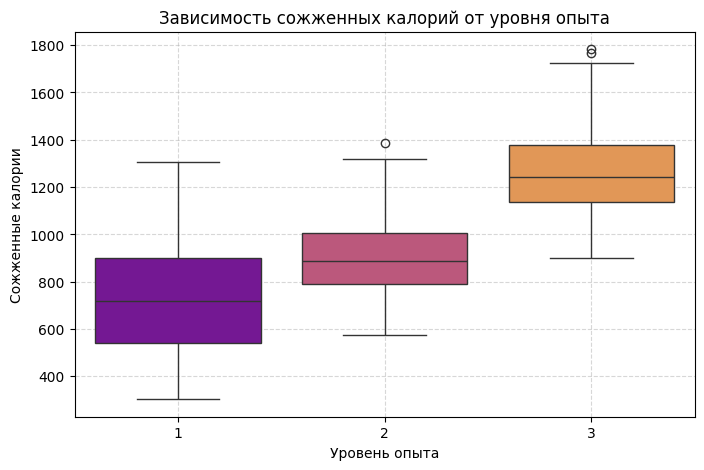

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Experience_Level', y='Calories_Burned', data=df, palette='plasma')

plt.xlabel("Уровень опыта")
plt.ylabel("Сожженные калории")
plt.title("Зависимость сожженных калорий от уровня опыта")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()